In [1]:
import pybamm
import numpy as np
import matplotlib.pyplot as plt
import time
from collections import defaultdict

In [2]:
temps_C = [0, 10, 25, 45]     # temperature sweep in Celsius
C_rates = [1, 2]              # run both 1C and 2C
V_cutoff = 2.7                # cutoff voltage

# Base parameter set
base_param = pybamm.ParameterValues("Chen2020")

# Model: SPMe includes electrolyte physics (important for low T / high C)
model = pybamm.lithium_ion.SPMe()

# Store results
results = defaultdict(dict)   # results[C_rate][T] = {"solution": sol, "runtime_s": ...}
metrics = defaultdict(dict)   # metrics[C_rate][T] = {...}


In [3]:
for C in C_rates:
    for T in temps_C:
        experiment = pybamm.Experiment([f"Discharge at {C}C until {V_cutoff} V"])
        
        # Copy parameters and set ambient temperature
        param = base_param.copy()
        param.update({"Ambient temperature [K]": 273.15 + T})
        
        sim = pybamm.Simulation(
            model,
            parameter_values=param,
            experiment=experiment
        )
        
        t0 = time.time()
        sol = sim.solve()
        runtime = time.time() - t0
        
        results[C][T] = {"solution": sol, "runtime_s": runtime}
        
        print(f"Finished: {C}C @ {T}°C  | runtime = {runtime:.2f} s")


Finished: 1C @ 0°C  | runtime = 0.55 s
Finished: 1C @ 10°C  | runtime = 0.45 s
Finished: 1C @ 25°C  | runtime = 0.33 s
Finished: 1C @ 45°C  | runtime = 0.41 s
Finished: 2C @ 0°C  | runtime = 0.39 s
Finished: 2C @ 10°C  | runtime = 0.43 s
Finished: 2C @ 25°C  | runtime = 0.42 s
Finished: 2C @ 45°C  | runtime = 0.39 s


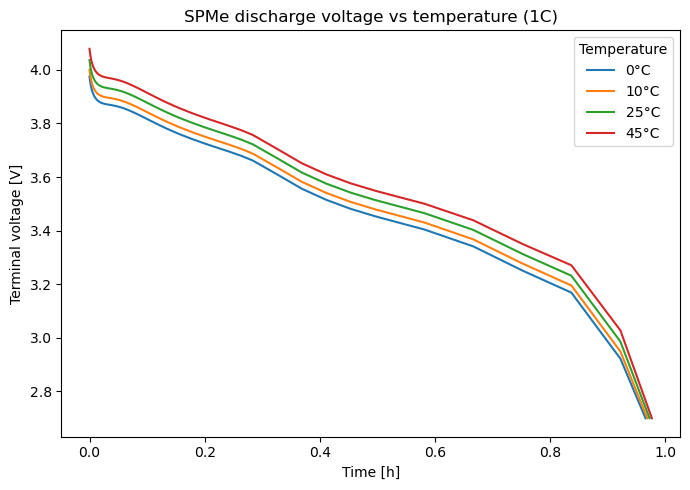

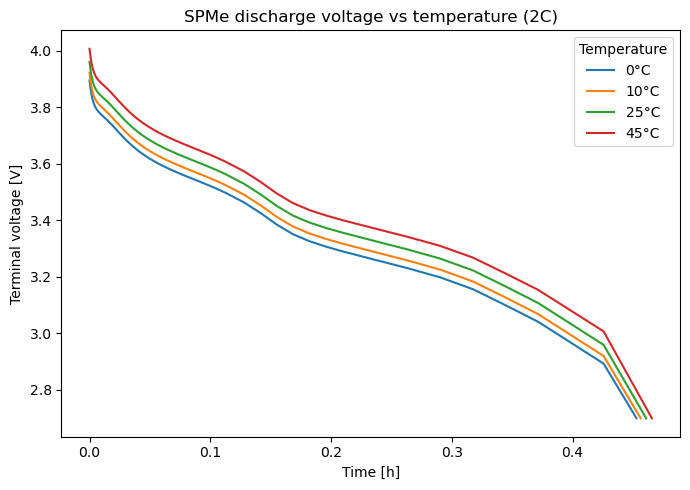

In [4]:
for C in C_rates:
    plt.figure(figsize=(7,5))
    for T in temps_C:
        sol = results[C][T]["solution"]
        t_h = sol["Time [h]"].entries
        V = sol["Terminal voltage [V]"].entries
        plt.plot(t_h, V, label=f"{T}°C")
    
    plt.xlabel("Time [h]")
    plt.ylabel("Terminal voltage [V]")
    plt.title(f"SPMe discharge voltage vs temperature ({C}C)")
    plt.legend(title="Temperature")
    plt.tight_layout()
    plt.savefig(f"../figures/spme_temp_sweep_{C}C_voltage.png", dpi=300)
    plt.show()


In [5]:
for C in C_rates:
    for T in temps_C:
        sol = results[C][T]["solution"]
        t_h = sol["Time [h]"].entries
        V = sol["Terminal voltage [V]"].entries
        
        t_end_h = float(t_h[-1])
        V_mean = float(np.mean(V))
        
        # Numerical integral of V over time (V·h)
        energy_Vh = float(np.trapz(V, t_h))
        
        metrics[C][T] = {
            "t_end_h": t_end_h,
            "V_mean": V_mean,
            "energy_Vh": energy_Vh,
            "runtime_s": float(results[C][T]["runtime_s"])
        }

metrics


defaultdict(dict,
            {1: {0: {'t_end_h': 0.9653894791065037,
               'V_mean': 3.8128286583486863,
               'energy_Vh': 3.3397265948083916,
               'runtime_s': 0.5471627712249756},
              10: {'t_end_h': 0.9685006964626028,
               'V_mean': 3.838289519920373,
               'energy_Vh': 3.3730941866171307,
               'runtime_s': 0.44806909561157227},
              25: {'t_end_h': 0.9724022268442306,
               'V_mean': 3.873310213034101,
               'energy_Vh': 3.417513847227578,
               'runtime_s': 0.32837581634521484},
              45: {'t_end_h': 0.976430474851625,
               'V_mean': 3.9117758976253336,
               'energy_Vh': 3.4636743982067597,
               'runtime_s': 0.40822553634643555}},
             2: {0: {'t_end_h': 0.45285635125654733,
               'V_mean': 3.669008696102986,
               'energy_Vh': 1.4887285644531072,
               'runtime_s': 0.39197850227355957},
              10:

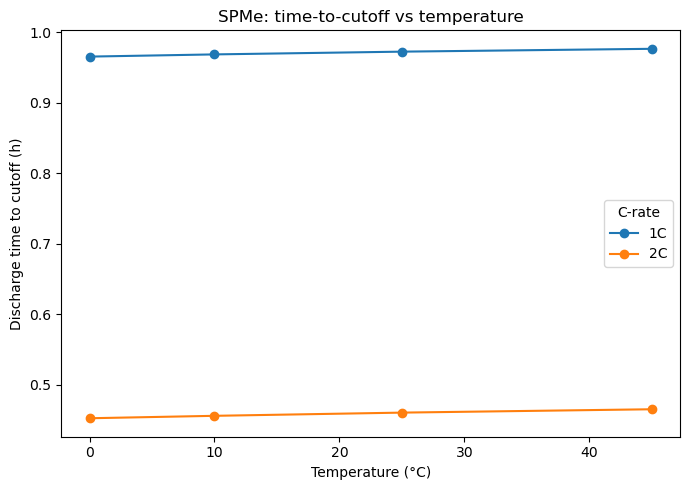

In [6]:
plt.figure(figsize=(7,5))

for C in C_rates:
    y = [metrics[C][T]["t_end_h"] for T in temps_C]
    plt.plot(temps_C, y, marker="o", label=f"{C}C")

plt.xlabel("Temperature (°C)")
plt.ylabel("Discharge time to cutoff (h)")
plt.title("SPMe: time-to-cutoff vs temperature")
plt.legend(title="C-rate")
plt.tight_layout()
plt.savefig("../figures/spme_temp_sweep_time_to_cutoff.png", dpi=300)
plt.show()


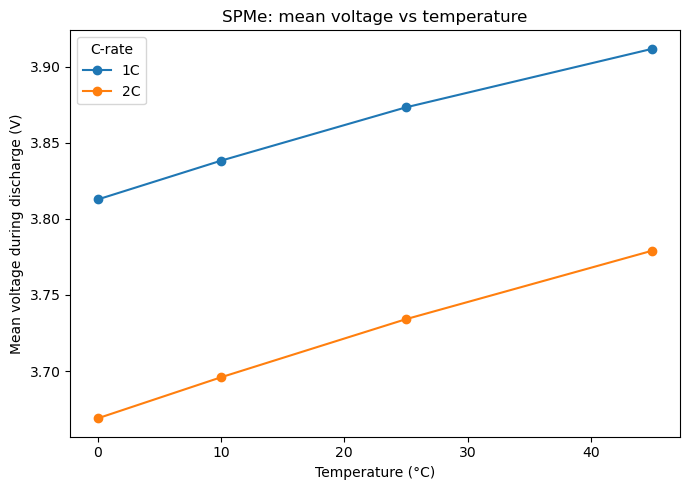

In [7]:
plt.figure(figsize=(7,5))

for C in C_rates:
    y = [metrics[C][T]["V_mean"] for T in temps_C]
    plt.plot(temps_C, y, marker="o", label=f"{C}C")

plt.xlabel("Temperature (°C)")
plt.ylabel("Mean voltage during discharge (V)")
plt.title("SPMe: mean voltage vs temperature")
plt.legend(title="C-rate")
plt.tight_layout()
plt.savefig("../figures/spme_temp_sweep_mean_voltage.png", dpi=300)
plt.show()


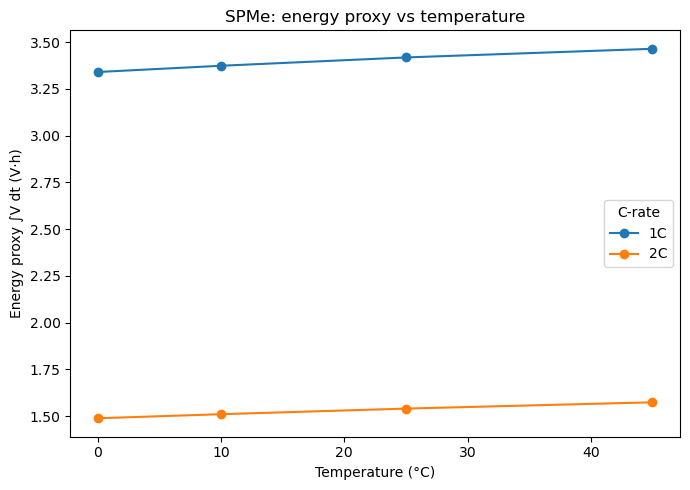

In [8]:
plt.figure(figsize=(7,5))

for C in C_rates:
    y = [metrics[C][T]["energy_Vh"] for T in temps_C]
    plt.plot(temps_C, y, marker="o", label=f"{C}C")

plt.xlabel("Temperature (°C)")
plt.ylabel("Energy proxy ∫V dt (V·h)")
plt.title("SPMe: energy proxy vs temperature")
plt.legend(title="C-rate")
plt.tight_layout()
plt.savefig("../figures/spme_temp_sweep_energy_proxy.png", dpi=300)
plt.show()


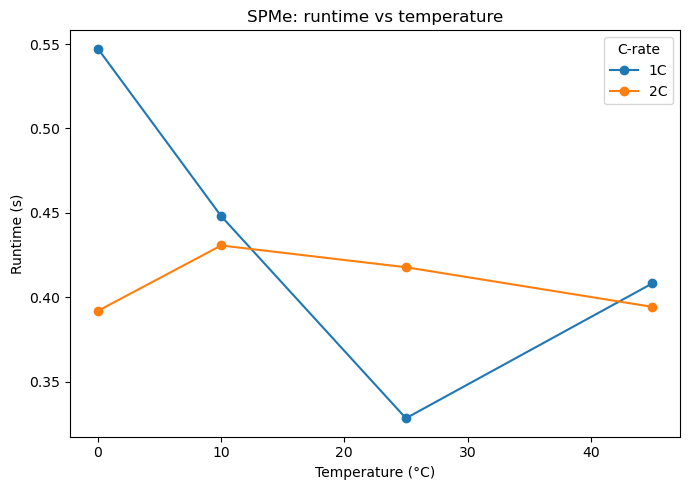

In [9]:
plt.figure(figsize=(7,5))

for C in C_rates:
    y = [metrics[C][T]["runtime_s"] for T in temps_C]
    plt.plot(temps_C, y, marker="o", label=f"{C}C")

plt.xlabel("Temperature (°C)")
plt.ylabel("Runtime (s)")
plt.title("SPMe: runtime vs temperature")
plt.legend(title="C-rate")
plt.tight_layout()
plt.savefig("../figures/spme_temp_sweep_runtime.png", dpi=300)
plt.show()


In [10]:
import pandas as pd

rows = []
for C in C_rates:
    for T in temps_C:
        m = metrics[C][T]
        rows.append({
            "C_rate": C,
            "Temp_C": T,
            "t_end_h": m["t_end_h"],
            "V_mean": m["V_mean"],
            "energy_Vh": m["energy_Vh"],
            "runtime_s": m["runtime_s"]
        })

df = pd.DataFrame(rows).sort_values(["C_rate", "Temp_C"])
df


,C_rate,Temp_C,t_end_h,V_mean,energy_Vh,runtime_s
0,1,0,0.965389,3.812829,3.339727,0.547163
1,1,10,0.968501,3.838290,3.373094,0.448069
2,1,25,0.972402,3.873310,3.417514,0.328376
3,1,45,0.976430,3.911776,3.463674,0.408226
4,2,0,0.452856,3.669009,1.488729,0.391979
5,2,10,0.456302,3.695964,1.510379,0.430686
6,2,25,0.460839,3.734108,1.540355,0.417803
7,2,45,0.465600,3.779126,1.573972,0.394341


As temperature decreases, reaction kinetics and transport slow down, increasing polarization and reaching cutoff earlier (reduced usable capacity under load).

At higher temperature, overpotentials reduce and voltage stays higher for longer, increasing discharge time and energy proxy.

The effect is stronger at higher C-rate (2C) because transport/kinetic limitations are amplified.